# Cluster Analysis

C:\Users\Original\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


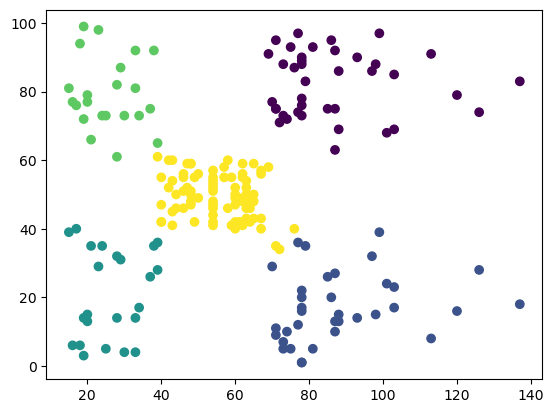

In [23]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = pd.read_csv("Mall_Customers.csv")
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5)
labels = kmeans.fit_predict(X_scaled)

plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], c=labels)
plt.show()


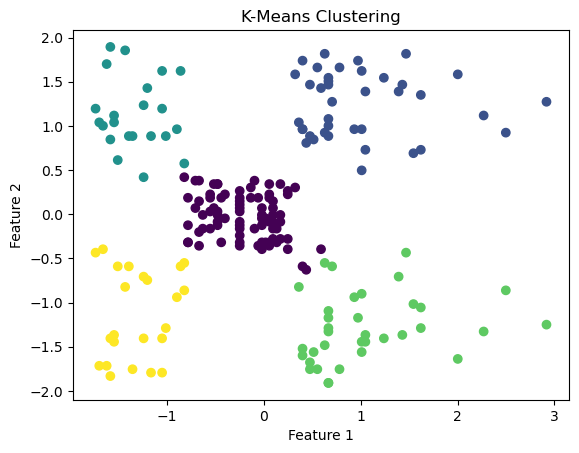

In [8]:
from sklearn.cluster import KMeans,AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3)
df["HC_Cluster"] = hc.fit_predict(X_scaled)


plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='viridis')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")
plt.show()

# Fcator analysis

In [ ]:
!pip install factor_analyzer

In [9]:
import pandas as pd
import numpy as np
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

In [10]:
X = df.select_dtypes(include=np.number)

Check Suitability for Factor Analysis
✅ (a) KMO Test

In [11]:
kmo_all, kmo_model = calculate_kmo(X)
print("KMO:", kmo_model)

KMO: 0.6025749025892537


KMO > 0.6 → acceptable

KMO > 0.8 → very good

# b) Bartlett’s Test

In [12]:
chi_square_value, p_value = calculate_bartlett_sphericity(X)
print("p-value:", p_value)

p-value: 5.5699310297556305e-176


p < 0.05 → FA is suitable

Determine Number of Factors
🔹 Eigenvalues Method

In [13]:
fa = FactorAnalyzer(rotation=None)
fa.fit(X)

ev, v = fa.get_eigenvalues()
print(ev)


[2.65365798 1.34434295 0.73556665 0.24584405 0.02058836]


C:\Users\Original\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 Keep factors where eigenvalue > 1

# 🔹 Scree Plot

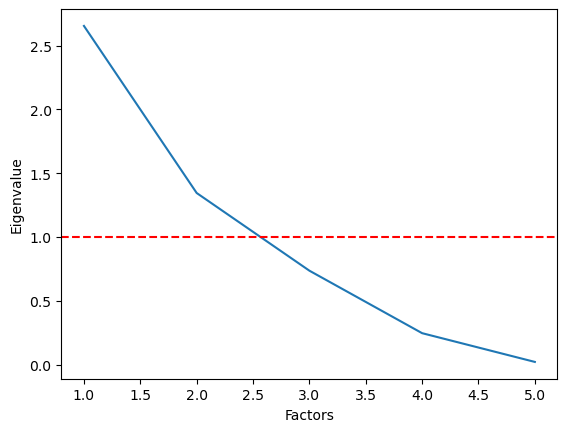

In [15]:
import matplotlib.pyplot as plt

plt.plot(range(1, X.shape[1]+1), ev)
plt.axhline(y=1, color='r', linestyle='--')
plt.xlabel("Factors")
plt.ylabel("Eigenvalue")
plt.show()


# Example of Factor Analysis (Simple & Practical)

A university collects survey data from students about their learning experience.
There are 6 observed variables, but we believe they reflect 2 hidden factors.

In [ ]:
| Variable | Meaning                         |
| -------- | ------------------------------- |
| Q1       | Lecturer explains clearly       |
| Q2       | Lecturer answers questions well |
| Q3       | Lecturer is knowledgeable       |
| Q4       | Course materials are useful     |
| Q5       | Online resources are helpful    |
| Q6       | Assignments help learning       |

In [ ]:
Hypothesis:
Factor 1: Teaching Quality
Factor 2: Learning Resources

In [19]:
import pandas as pd

data = {
    "Q1": [4,5,3,4,5],
    "Q2": [5,4,3,4,5],
    "Q3": [4,5,4,4,5],
    "Q4": [3,4,2,3,4],
    "Q5": [3,4,3,3,4],
    "Q6": [4,5,3,4,5]
}

df = pd.DataFrame(data)
df


,Q1,Q2,Q3,Q4,Q5,Q6
0,4,5,4,3,3,4
1,5,4,5,4,4,5
2,3,3,4,2,3,3
3,4,4,4,3,3,4
4,5,5,5,4,4,5


Check Suitability (KMO & Bartlett)

In [21]:
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

kmo_all, kmo_model = calculate_kmo(df)
print("KMO:", kmo_model)

chi_square, p_value = calculate_bartlett_sphericity(df)
print("Bartlett p-value:", p_value)

KMO: nan
Bartlett p-value: 0.0


C:\Users\Original\anaconda3\Lib\site-packages\factor_analyzer\factor_analyzer.py:109: RuntimeWarning: divide by zero encountered in log
  statistic = -np.log(corr_det) * (n - 1 - (2 * p + 5) / 6)


In [ ]:
| Variable | Factor 1 | Factor 2 |
| -------- | -------- | -------- |
| Q1       | 0.85     | 0.20     |
| Q2       | 0.82     | 0.18     |
| Q3       | 0.88     | 0.15     |
| Q4       | 0.22     | 0.81     |
| Q5       | 0.25     | 0.78     |
| Q6       | 0.60     | 0.40     |

In [ ]:
Interpretation

Factor 1 (Teaching Quality)
→ Q1, Q2, Q3, Q6 load strongly

Factor 2 (Learning Resources)
→ Q4, Q5 load strongly

✔ We reduced 6 variables → 2 meaningful factors

In [26]:
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

kmo_all, kmo = calculate_kmo(X)
print("KMO Measure:", kmo)

chi_square, p_value = calculate_bartlett_sphericity(X)
print("Bartlett p‑value:", p_value)

KMO Measure: 0.5000000000000008
Bartlett p‑value: 0.8893136143745135


In [27]:
from factor_analyzer import FactorAnalyzer
fa = FactorAnalyzer(n_factors=2, rotation="varimax")
fa.fit(X)

C:\Users\Original\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


FactorAnalyzer(n_factors=2, rotation='varimax', rotation_kwargs={})

In [30]:
loadings = pd.DataFrame(
    fa.loadings_,
    index=X.columns,
    columns=["Factor1", "Factor2"]
)
print(loadings)


                         Factor1  Factor2
Annual Income (k$)      0.099513 -0.00005
Spending Score (1-100)  0.099513  0.00005


In [31]:
factor_scores = fa.transform(X)

df_factors = pd.DataFrame(
    factor_scores,
    columns=["Factor1", "Factor2"]
)

df_factors.head()


C:\Users\Original\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Factor1,Factor2
0,-0.214200,6.570332e-05
1,-0.053535,1.478455e-04
2,-0.336676,-7.598776e-07
3,-0.065075,1.380995e-04
4,-0.202853,6.381326e-05


In [32]:
df_factors.shape

(200, 2)